In [2]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

In [3]:
!pip install vllm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 433.1/433.1 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.3/194.3 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.7/267.7 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 662.1/662.1 kB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.2/114.2 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0

In [1]:
from unsloth import PatchFastRL
from unsloth import FastLanguageModel
PatchFastRL("GRPO", FastLanguageModel)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: UnslothAlignPropTrainer is already patched.
Unsloth: UnslothBCOTrainer is already patched.
Unsloth: UnslothCPOTrainer is already patched.
Unsloth: UnslothDDPOTrainer is already patched.
Unsloth: UnslothDPOTrainer is already patched.
Unsloth: UnslothGKDTrainer is already patched.
Unsloth: UnslothGRPOTrainer is already patched.
Unsloth: UnslothIterativeSFTTrainer is already patched.
Unsloth: UnslothKTOTrainer is already patched.
Unsloth: UnslothNashMDTrainer is already patched.
Unsloth: UnslothOnlineDPOTrainer is already patched.
Unsloth: UnslothORPOTrainer is already patched.
Unsloth: UnslothPPOTrainer is already patched.
Unsloth: UnslothPRMTrainer is already patched.
Unsloth: UnslothRewardTrainer is already patched.
Unsloth: UnslothRLOOTrainer is already patched.
Unsloth: UnslothSFTTrainer is already patched.
Unsloth: UnslothXPOTrainer is al

In [2]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 2048
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Llama-3.2-1B-bnb-4bit",
    max_seq_length=max_seq_length,
    dtype=None,
    load_in_4bit=True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
)

==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 4.56.2. vLLM: 0.19.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.03G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/230 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/459 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

Unsloth 2026.4.8 patched 16 layers with 16 QKV layers, 16 O layers and 16 MLP layers.


In [3]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
)
model.print_trainable_parameters()

Unsloth: Already have LoRA adapters! We shall skip this step.


trainable params: 11,272,192 || all params: 1,247,086,592 || trainable%: 0.9039


In [4]:
import json
from collections import defaultdict
from datasets import Dataset

FINAL_SCORE_THRESHOLD = 0.70   # only use episodes where agent scored > 0.70
SYSTEM_PROMPT = """You are an expert hiring manager making sequential decisions to assemble the best team within a strict budget.

ACTIONS — respond with exactly one JSON object:
  {"action": "interview", "candidate_id": "C03"}   → costs 10 units, reveals interview_score
  {"action": "probe",     "candidate_id": "C03"}   → costs 20 units, requires prior interview, audits coaching risk
  {"action": "hire",      "candidate_id": "C03"}   → costs 50 units, adds to your team
  {"action": "skip",      "candidate_id": "C03"}   → free, permanently rejects
  {"action": "finalize"}                            → ends episode, scores your team

RULES:
- Resume score is noisy — never hire based on it alone.
- Always interview before hiring. Blind hires are penalized.
- probe after interview if interview_score looks suspicious (high resume, low interview or vice versa).
- You MUST call finalize to receive your score.
- Budget exhaustion ends the episode automatically.

Respond with ONLY a JSON object on the last line. No extra text."""


def load_and_filter_episodes(jsonl_path, threshold=FINAL_SCORE_THRESHOLD):
    """
    Load JSONL, group by episode_id, keep only episodes with final_score > threshold.
    For each step in a kept episode, yield (prompt_messages, executed_action_json).
    """
    rows = []
    with open(jsonl_path) as f:
        for line in f:
            rows.append(json.loads(line.strip()))

    # Group by episode
    episodes = defaultdict(list)
    for r in rows:
        episodes[r["episode_id"]].append(r)

    sft_rows = []
    kept_episodes = 0
    for ep_id, steps in episodes.items():
        # Find the final score for this episode
        final_steps = [s for s in steps if s.get("done") and s.get("final_score") is not None]
        if not final_steps:
            continue
        final_score = max(s["final_score"] for s in final_steps)
        if final_score < threshold:
            continue

        kept_episodes += 1
        # Sort steps by step number
        steps_sorted = sorted(steps, key=lambda s: s.get("step", 0))

        for step in steps_sorted:
            executed = step.get("executed_action")
            if not executed:
                continue

            # Get the user-facing dashboard content (last message in prompt)
            prompt_msgs = step.get("prompt", [])
            if not prompt_msgs:
                continue
            dashboard = prompt_msgs[-1]["content"] if isinstance(prompt_msgs, list) else str(prompt_msgs)

            # Build clean messages: our system prompt + dashboard as user turn
            messages = [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user",   "content": dashboard},
            ]

            # Target completion: just the action JSON, clean
            completion = json.dumps(executed)

            sft_rows.append({
                "messages": messages,
                "completion": completion,
                "task": step.get("task", "easy"),
                "final_score": final_score,
                "step_reward": step.get("reward", 0.0),
            })

    print(f"Kept {kept_episodes} episodes with final_score > {threshold}")
    print(f"Total SFT training pairs: {len(sft_rows)}")
    return sft_rows


train_rows = load_and_filter_episodes("/content/drive/MyDrive/Colab Notebooks/Agent-Hire-Arena/data/grpo_agenthire_train.jsonl")
val_rows   = load_and_filter_episodes("/content/drive/MyDrive/Colab Notebooks/Agent-Hire-Arena/data/grpo_agenthire_val.jsonl", threshold=0.5)

# Sanity check
print("\nSample train row:")
print("  messages roles:", [m["role"] for m in train_rows[0]["messages"]])
print("  completion:", train_rows[0]["completion"])
print("  final_score:", train_rows[0]["final_score"])


Kept 35 episodes with final_score > 0.7
Total SFT training pairs: 248
Kept 10 episodes with final_score > 0.5
Total SFT training pairs: 24

Sample train row:
  messages roles: ['system', 'user']
  completion: {"action": "interview", "candidate_id": "C03"}
  final_score: 0.9162795637204757


In [5]:
# ── CELL 4: Format for Unsloth SFT (prompt+completion as single string) ──────
from unsloth.chat_templates import get_chat_template

tokenizer = get_chat_template(tokenizer, chat_template="llama-3.1")

EOS = tokenizer.eos_token

def format_sft_example(row):
    """
    Converts messages + completion into a single training string.
    Unsloth SFTTrainer with train_on_responses_only will mask the prompt portion.
    """
    # Apply chat template to the prompt messages only (no generation prompt yet)
    prompt_str = tokenizer.apply_chat_template(
        row["messages"],
        tokenize=False,
        add_generation_prompt=True,   # adds the assistant turn start token
    )
    # Append the target completion + EOS
    full_text = prompt_str + row["completion"] + EOS
    return {"text": full_text}


train_data = [format_sft_example(r) for r in train_rows]
val_data   = [format_sft_example(r) for r in val_rows]

train_dataset = Dataset.from_list(train_data)
val_dataset   = Dataset.from_list(val_data)

print(f"\nTrain dataset: {len(train_dataset)} rows")
print(f"Val dataset:   {len(val_dataset)} rows")
print("\nSample text (first 500 chars):")
print(train_dataset[0]["text"][:500])


Train dataset: 248 rows
Val dataset:   24 rows

Sample text (first 500 chars):
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 July 2024

You are an expert hiring manager making sequential decisions to assemble the best team within a strict budget.

ACTIONS — respond with exactly one JSON object:
  {"action": "interview", "candidate_id": "C03"}   → costs 10 units, reveals interview_score
  {"action": "probe",     "candidate_id": "C03"}   → costs 20 units, requires prior interview, audits coaching risk
  {"ac


In [6]:
from trl import SFTTrainer, SFTConfig

training_args = SFTConfig(
    output_dir="agenthire_sft_output",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    learning_rate=2e-4,
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    logging_steps=5,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    weight_decay=0.01,
    optim="adamw_8bit",
    seed=3407,
    report_to="none",
    max_seq_length=max_seq_length,
    packing=False,
    completion_only_loss=True,   # ← moved here
)

trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,  # ← not tokenizer=
    args=training_args,
    train_dataset=train_dataset,  # must have "prompt" + "completion" columns
    eval_dataset=val_dataset,
)

print("Starting SFT training...")
trainer_stats = trainer.train()
print("Done!", trainer_stats)

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/248 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/24 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
Starting SFT training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 248 | Num Epochs = 3 | Total steps = 93
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 11,272,192 of 1,247,086,592 (0.90% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
5,2.543900
10,2.203300
15,1.539000
20,0.815400
25,0.458100
30,0.338800
35,0.252000
40,0.189700
45,0.151500
50,0.135400


Done! TrainOutput(global_step=93, training_loss=0.518600994540799, metrics={'train_runtime': 273.6215, 'train_samples_per_second': 2.719, 'train_steps_per_second': 0.34, 'total_flos': 3169191004655616.0, 'train_loss': 0.518600994540799, 'epoch': 3.0})


    RAW:    {"action": "interview", "candidate_id": "C01"}
    PARSED: {'action': 'interview', 'candidate_id': 'C01'}
    OBS done=False budget=300.0 hires=[]
    RAW:    {"action": "interview", "candidate_id": "C03"}
    PARSED: {'action': 'interview', 'candidate_id': 'C03'}
    OBS done=False budget=290.0 hires=[]
    RAW:    {"action": "interview", "candidate_id": "C04"}
    PARSED: {'action': 'interview', 'candidate_id': 'C04'}
    OBS done=False budget=280.0 hires=[]
    RAW:    {"action": "interview", "candidate_id": "C03"}
    PARSED: {'action': 'interview', 'candidate_id': 'C03'}
    OBS done=False budget=270.0 hires=[]
    RAW:    {"action": "finalize"}
    PARSED: {'action': 'finalize'}
    OBS done=False budget=220.0 hires=['C01']
    FINAL: score=0.9943837566218385 hires=['C01'] steps=5
  easy ep1: 0.994
    RAW:    {"action": "interview", "candidate_id": "C01"}
    PARSED: {'action': 'interview', 'candidate_id': 'C01'}
    OBS done=False budget=300.0 hires=[]
    RAW:    {

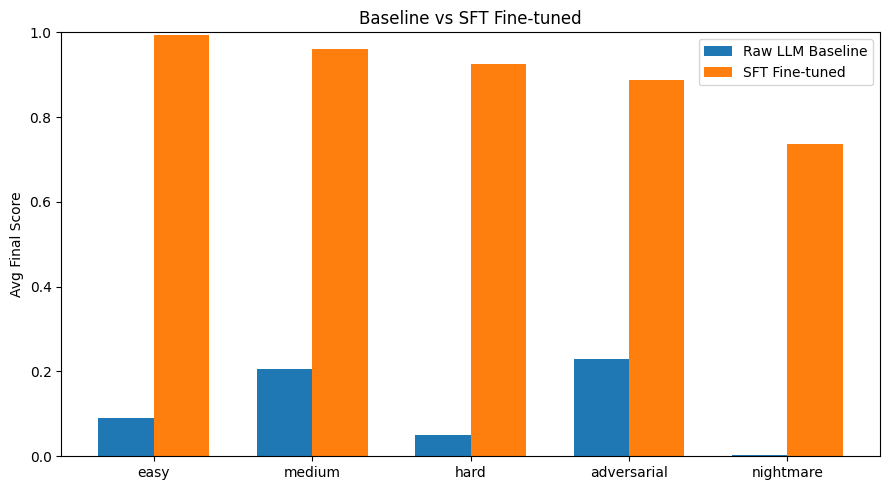

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import os, sys, torch
from unsloth import FastLanguageModel

os.environ["DISABLE_LIVE_PROBE_JUDGE"] = "1"
os.chdir("/content/drive/MyDrive/Colab Notebooks/Agent-Hire-Arena")
if "/content/drive/MyDrive/Colab Notebooks/Agent-Hire-Arena" not in sys.path:
    sys.path.insert(0, "/content/drive/MyDrive/Colab Notebooks/Agent-Hire-Arena")

from server.environment import HiringEnvironment
from models import HiringAction
from inference import render_observation, parse_action

FastLanguageModel.for_inference(model)

TASK_LEVELS = ["easy", "medium", "hard", "adversarial", "nightmare"]
N_EPISODES = 5
def safe_action(action_dict, obs):
    # never finalize with empty team
    if action_dict is None:
        action_dict = {"action": "finalize"}

    act = action_dict.get("action")
    cid = action_dict.get("candidate_id")

    # live candidates
    live = [c for c in obs.candidates if c["candidate_id"] not in obs.hires_made and c["candidate_id"] not in obs.skipped]
    interviewed = {c["candidate_id"]: obs.interviews_done[c["candidate_id"]] for c in live if c["candidate_id"] in obs.interviews_done}

    # 1) block empty finalize
    if act == "finalize" and len(obs.hires_made) == 0:
        if interviewed:
            best = max(interviewed, key=interviewed.get)
            return {"action": "hire", "candidate_id": best}
        # else get signal first
        target = max(live, key=lambda x: x["resume_score"])["candidate_id"]
        return {"action": "interview", "candidate_id": target}

    # 2) invalid probe -> interview same cid
    if act == "probe" and (cid not in obs.interviews_done):
        return {"action": "interview", "candidate_id": cid}

    # 3) duplicate interview -> hire best interviewed
    if act == "interview" and cid in obs.interviews_done and interviewed:
        best = max(interviewed, key=interviewed.get)
        return {"action": "hire", "candidate_id": best}

    return action_dict
def run_episode(task: str) -> float:
    env = HiringEnvironment()
    obs = env.reset(task=task)

    for _ in range(obs.max_steps):
        if obs.done:
            break

        dashboard = render_observation(obs)
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": dashboard},
        ]

        enc = tokenizer.apply_chat_template(
            messages,
            tokenize=True,
            add_generation_prompt=True,
            return_tensors="pt",
            return_dict=True,
        ).to(model.device)

        with torch.no_grad():
            out = model.generate(
                input_ids=enc["input_ids"],
                attention_mask=enc["attention_mask"],
                max_new_tokens=64,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )

        gen_ids = out[0][enc["input_ids"].shape[1]:]
        text = tokenizer.decode(gen_ids, skip_special_tokens=True)
        action_dict = parse_action(text)  # fixed: parse before printing

        print(f"    RAW:    {text[:200]}")
        print(f"    PARSED: {action_dict}")
        print(f"    OBS done={obs.done} budget={obs.budget_remaining} hires={obs.hires_made}")

        action_dict = parse_action(text)   # or parse_action(text)
        action_dict = safe_action(action_dict, obs)
        action = HiringAction(**action_dict)
        obs, reward = env.step(action)

    # force finalize if loop exhausted without done
    if not obs.done:
        env.step(HiringAction(action="finalize"))

    state = env.state()
    print(f"    FINAL: score={state.get('final_score')} hires={state.get('hires_made')} steps={state.get('step_num')}")
    return state.get("final_score") or 0.0


# --- Run evaluation ---
results = {}
for task in TASK_LEVELS:
    scores = []
    for ep in range(N_EPISODES):
        try:
            s = run_episode(task)
            scores.append(s)
            print(f"  {task} ep{ep+1}: {s:.3f}")
        except Exception as e:
            import traceback; traceback.print_exc()
            print(f"  {task} ep{ep+1}: ERROR {e}")
            scores.append(0.0)
    results[task] = np.mean(scores)
    print(f"{task}: avg={results[task]:.3f}")

# --- Plot ---
baseline = {"easy": 0.09, "medium": 0.205, "hard": 0.05, "adversarial": 0.23, "nightmare": 0.002}

x = np.arange(len(TASK_LEVELS))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, [baseline[t] for t in TASK_LEVELS], width, label="Raw LLM Baseline", color="#1f77b4")
ax.bar(x + width/2, [results[t]  for t in TASK_LEVELS], width, label="SFT Fine-tuned",   color="#ff7f0e")

ax.set_ylim(0, 1.0)
ax.set_ylabel("Avg Final Score")
ax.set_title("Baseline vs SFT Fine-tuned")
ax.set_xticks(x)
ax.set_xticklabels(TASK_LEVELS)
ax.legend()
ax.axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.savefig("sft_eval.png", dpi=150)
plt.show()

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# before = old trainer logs, after = new trainer logs
# if you only have one trainer object now, keep "after_logs = trainer.state.log_history"
before_logs = before_trainer.state.log_history
after_logs  = trainer.state.log_history

KEY = "rewards/agent_hire_reward_func/mean"  # change if your key differs

def to_df(logs, label):
    rows = [{"step": x["step"], "reward": x[KEY], "run": label}
            for x in logs if "step" in x and KEY in x]
    return pd.DataFrame(rows)

df = pd.concat([
    to_df(before_logs, "Before fix"),
    to_df(after_logs,  "After fix"),
], ignore_index=True)

plt.figure(figsize=(8,5))
for run, g in df.groupby("run"):
    plt.plot(g["step"], g["reward"], marker="o", label=run)

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Training step")
plt.ylabel("Avg reward")
plt.title("Reward Curve: Before vs After")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'before_trainer' is not defined

In [21]:
def agent_hire_reward_func(prompts, completions, task=None, tasks=None, **kwargs):
    # robust task source
    task_batch = tasks if tasks is not None else task
    if isinstance(task_batch, str):
        task_batch = [task_batch] * len(prompts)
    if task_batch is None:
        task_batch = ["easy"] * len(prompts)  # fallback
if not action_dict or "action" not in action_dict:
    action_dict = {"action": "finalize"}

NameError: name 'action_dict' is not defined

In [12]:
# 1. Check your completion field distribution
import json
from collections import Counter

actions = []
with open("/content/drive/MyDrive/Colab Notebooks/Agent-Hire-Arena/data/grpo_agenthire_train.jsonl") as f:
    for line in f:
        row = json.loads(line)
        c = row.get("completion", "")
        if '"hire"' in c:
            actions.append("hire")
        elif '"interview"' in c:
            actions.append("interview")
        elif '"finalize"' in c:
            actions.append("finalize")
        elif '"probe"' in c:
            actions.append("probe")
        elif '"skip"' in c:
            actions.append("skip")

print(Counter(actions))

Counter({'hire': 554, 'finalize': 388, 'probe': 103, 'skip': 102, 'interview': 11})


In [15]:
import json
from collections import defaultdict

# Group by episode_id
episodes = defaultdict(list)
with open("/content/drive/MyDrive/Colab Notebooks/Agent-Hire-Arena/data/grpo_agenthire_train.jsonl") as f:
    for line in f:
        row = json.loads(line)
        episodes[row["episode_id"]].append(row)

# Keep only episodes that have at least one interview step
good_episodes = [
    steps for steps in episodes.values()
    if any(json.loads(s["completion"]) if isinstance(s["completion"], str)
           else s["completion"]
           for s in steps
           if (s.get("executed_action") or {}).get("action") == "interview")
]

# Also filter by positive reward
with open("/content/drive/MyDrive/Colab Notebooks/Agent-Hire-Arena/data/grpo_agenthire_train.jsonl", "w") as f:
    for steps in good_episodes:
        for row in steps:
            f.write(json.dumps(row) + "\n")

print(f"Episodes kept: {len(good_episodes)} / {len(episodes)}")

JSONDecodeError: Extra data: line 1 column 46 (char 45)